In [1]:
import pandas as pd
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# File name
SMOTE_DATA_FILE_NAME = "loan_data_smoted_raw_train_4.csv"
RAW_DATA_FILE_NAME = "loan_data_raw_test_1.csv"
PROJECT_ROOT = Path("..")
SMOTE_DATA_FILE_PATH = PROJECT_ROOT / "data" / "smote" / SMOTE_DATA_FILE_NAME
RAW_DATA_FILE_PATH = PROJECT_ROOT / "data" / "raw" / RAW_DATA_FILE_NAME
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Smote data path:", SMOTE_DATA_FILE_PATH)
print("Raw data path:", RAW_DATA_FILE_PATH)

df = pd.read_csv(SMOTE_DATA_FILE_PATH)
print(df.shape)
df.head()

PROJECT_ROOT: ..
Smote data path: ..\data\smote\loan_data_smoted_raw_train_4.csv
Raw data path: ..\data\raw\loan_data_raw_test_1.csv
(53530, 13)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,31.0,female,2,44485.0,4,RENT,8000.0,PERSONAL,8.83,0.18,8.0,668,0
1,24.0,female,4,35851.0,0,RENT,8725.0,MEDICAL,12.18,0.24,2.0,645,0
2,28.0,female,1,121251.0,6,MORTGAGE,25000.0,VENTURE,11.01,0.21,6.0,569,1
3,23.0,female,1,76537.0,1,RENT,12000.0,MEDICAL,14.96,0.16,4.0,538,1
4,24.0,male,2,53633.0,4,RENT,23975.0,HOMEIMPROVEMENT,11.01,0.45,2.0,678,1


In [2]:
test_df = pd.read_csv(RAW_DATA_FILE_PATH)
print(test_df.shape)
test_df.head()

(8999, 13)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,24.0,male,4,100901.0,5,RENT,5000.0,HOMEIMPROVEMENT,16.35,0.05,3.0,602,0
1,34.0,male,2,96600.0,15,RENT,5000.0,HOMEIMPROVEMENT,6.17,0.05,10.0,614,0
2,29.0,male,3,75404.0,1,MORTGAGE,3104.0,PERSONAL,12.76,0.04,8.0,657,0
3,30.0,female,1,43211.0,5,OWN,10000.0,EDUCATION,6.04,0.23,9.0,645,0
4,22.0,female,4,58551.0,0,RENT,7228.0,PERSONAL,12.09,0.12,4.0,670,0


In [3]:
# Labels
target = "loan_status"

X_train = df.drop(columns=[target]).copy()
y_train = df[target].copy()
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_test = test_df.drop(columns=[target])
y_test = test_df[target].copy()
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]

cat_cols = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent"
]

col_names = numeric_cols + cat_cols
num_features = len(numeric_cols) + len(cat_cols)

X_train shape: (53530, 12)
y_train shape: (53530,)
X_test shape: (8999, 12)
y_test shape: (8999,)


In [4]:
import pennylane as qml
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

def encode_as_angles(X_array):
    angles = []
    
    # Numeric features map to [0, pi] since Pauli rotations are periodic 2pi
    for col in numeric_cols:
        scaler = MinMaxScaler(feature_range=(0, np.pi))
        # Append as matrix
        angles.append(scaler.fit_transform(X_array[[col]]))
        
    # Categorical features map evenly around circle
    for col in cat_cols:
        le = LabelEncoder()
        # Assign numbers 0 to num_categories-1 to categories
        ints = le.fit_transform(X_array[col])
        num_cats = len(cat_cols)
        cat_angles = (ints / num_cats) * 2 * np.pi
        # Append as list of column vectors
        angles.append(cat_angles.reshape(-1, 1))
        
    # convert list of angles into (nsamples x num_features)
    return np.hstack(angles)
    
# Encode training data and test data as angles
X_train_angle_encoded = encode_as_angles(X_train)
X_test_angle_encoded = encode_as_angles(X_test)

# Create dataframe of angle-encoded features
train_qelm_df = pd.DataFrame(X_train_angle_encoded, columns=col_names)
test_qelm_df = pd.DataFrame(X_test_angle_encoded, columns=col_names)

# Add target back so the output csv can be used directly for model training
train_qelm_df['target'] = y_train.values
test_qelm_df['target'] = y_test.values

# Save for later training
train_qelm_df.to_csv("train_qelm_angle_encoded_features.csv", index=False)
test_qelm_df.to_csv("test_angle_encoded_features.csv", index=False)

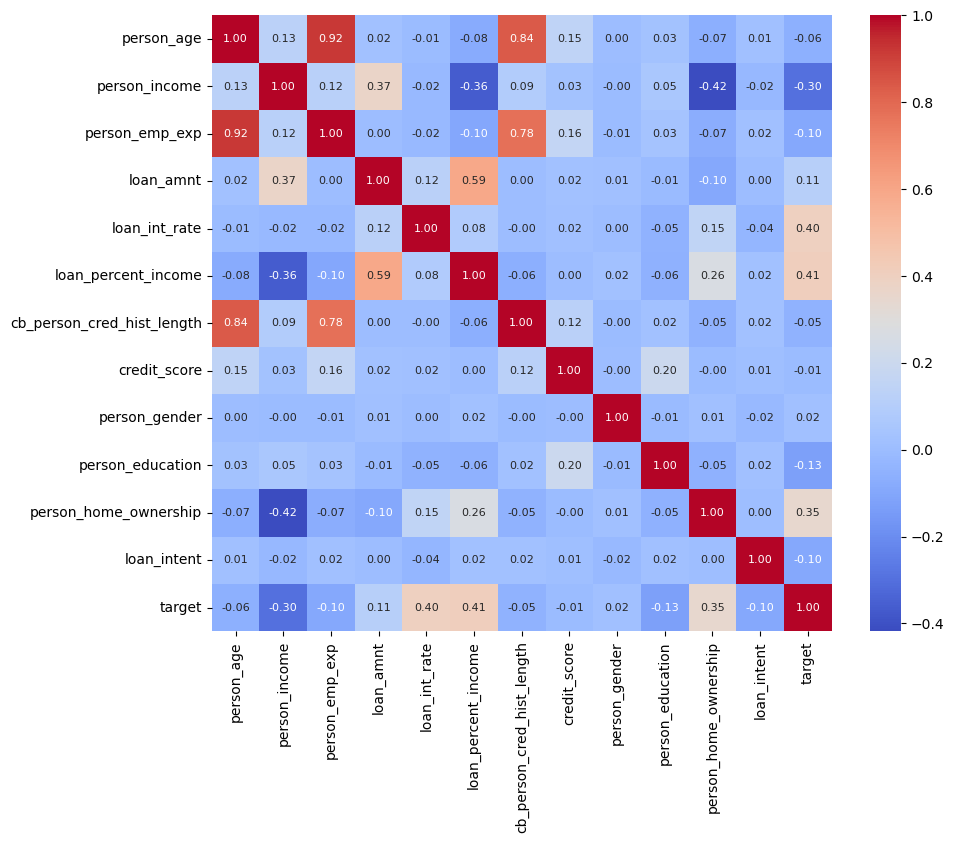

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_qelm_df.corr(), annot=True, cmap='coolwarm', annot_kws={"size": 8}, fmt=".2f")
plt.show()

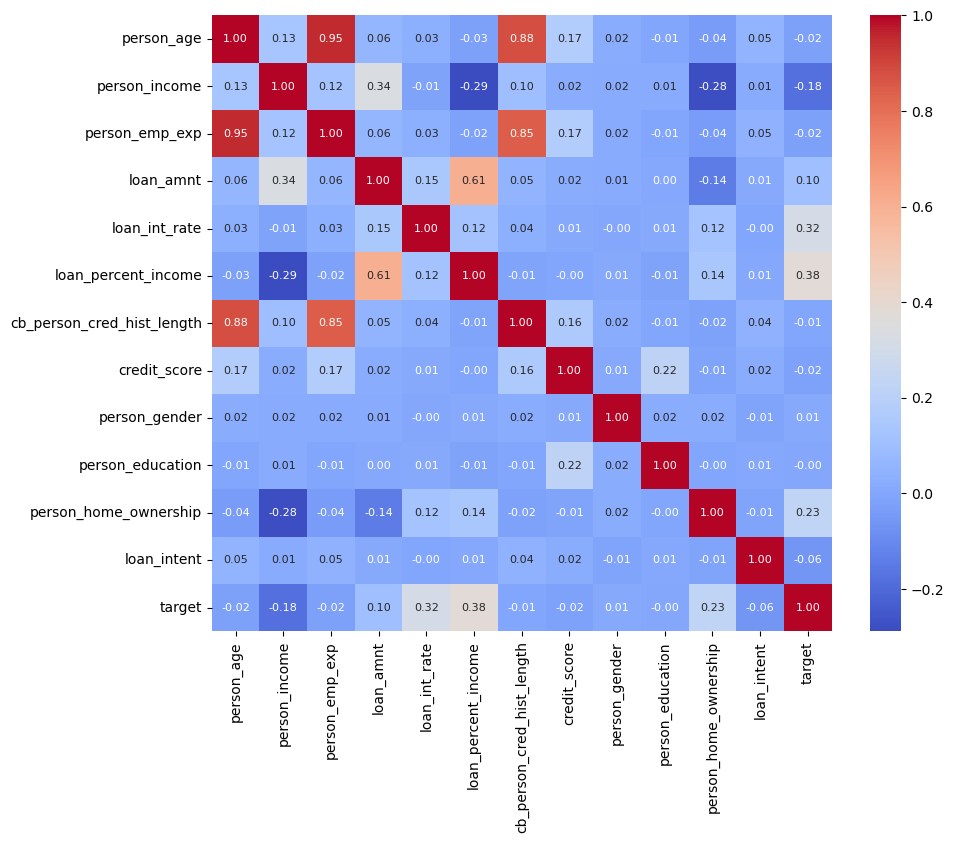

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(test_qelm_df.corr(), annot=True, cmap='coolwarm', annot_kws={"size": 8}, fmt=".2f")
plt.show()

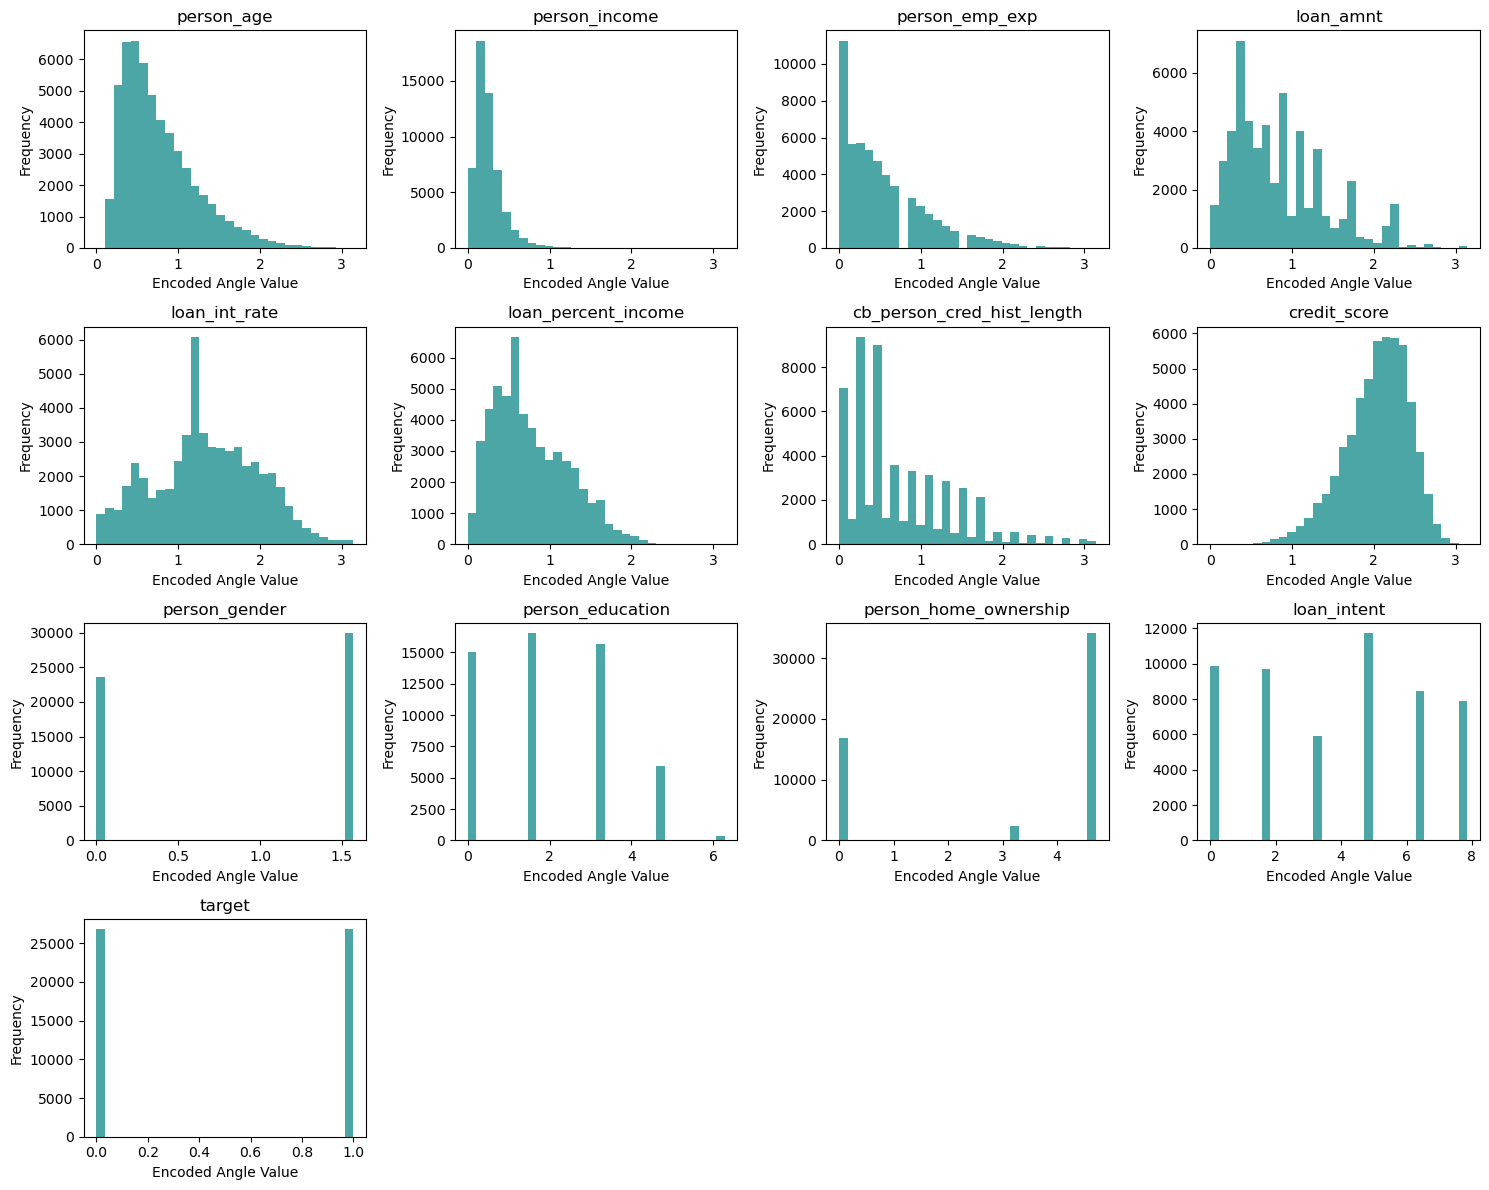

In [7]:
# Look at angle-encoded distributions

# Assuming qelm_df is already defined
# Use the column names from your dataframe
feature_names = train_qelm_df.columns

fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()

for i, name in enumerate(feature_names):
    axes[i].hist(train_qelm_df[name], bins=30, color='teal', alpha=0.7)
    axes[i].set_title(name) # Uses actual feature name here
    axes[i].set_xlabel('Encoded Angle Value')
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for i in range(len(feature_names), 16):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Encode features by applying Hadamard gates and RY rotations 
def encode_features(X_array):
    # Apply Hadamard gates to all qubits to create an equal superposition state
    for i in range(len(X_array)):
        qml.Hadamard(i)
        
    # Apply rotations from precomputed angles
    for i, angle in enumerate(X_array):
        qml.RY(angle, wires=i)


In [9]:
# Define n-layer quantum circuit with entanglements and random fixed rotations
def qelm_circuit(angles,n_layers):
    num_features = int(len(angles)/(2*n_layers))
    for n in range(n_layers):
            
        # First set of random rotations
        for i in range(num_features):
            qml.RY(angles[i + n*2*num_features], wires=i)
    
        # Cyclical CNOT gates
        qml.CNOT(wires=[num_features-1, 0])
        for i in range(num_features-1):
            target = (i + 1) % num_features
            qml.CNOT(wires=[i, target])
        
        # Second set or random rotations
        for i in range(num_features):
            qml.RY(angles[i + num_features + n*2*num_features], wires=i)
    
        # Cyclical CNOT gates in reverse order
        for i in reversed(range(num_features-1)):
            target = (i + 1) % num_features
            qml.CNOT(wires=[i, target])
        qml.CNOT(wires=[num_features-1, 0])  

In [10]:
dev = qml.device("default.qubit", wires=num_features)

@qml.qnode(dev)
def apply_qelm(features, random_angles, n_layers):
    num_features = len(features)
    encode_features(features)

    qelm_circuit(random_angles, n_layers)
    
    # Return the measurements
    # Single-qubit expectations
    obs = [qml.expval(qml.PauliZ(i)) for i in range(num_features)]
    
    # Add all pairwise combinations
    all_pairs = list(itertools.combinations(range(num_features), 2))
    obs += [qml.expval(qml.PauliZ(i) @ qml.PauliZ(j)) for i, j in all_pairs]
    # Neighbouring pairs only
    # obs += [qml.expval(qml.PauliZ(i) @ qml.PauliZ((i+1)%num_features)) for i in range(num_features)]
    return obs

n_layers = 2
# Set a seed for repeatability of experiments
seed = 333
rng = np.random.default_rng(seed)

# Generate a set of random angles for seed
random_angles = rng.random(n_layers * num_features)
    
results_train = []
for i in range(len(X_train_angle_encoded)):
    row = X_train_angle_encoded[i]
    # Execute circuit
    val = apply_qelm(row, random_angles, n_layers)
    results_train.append(val)

X_train_quantum = pd.DataFrame(np.array(results_train))
X_train_quantum.to_csv("X_train_quantum.csv", index=False)

results_test = []
for i in range(len(X_test_angle_encoded)):
    row = X_test_angle_encoded[i]
    # Execute circuit
    val = apply_qelm(row, random_angles, n_layers)
    results_test.append(val)

X_test_quantum = pd.DataFrame(np.array(results_test))
X_test_quantum.to_csv("X_test_quantum.csv", index=False)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Scale features to N(0,1) for logistic regression
scaler = StandardScaler()
X_train_quantum_scaled = scaler.fit_transform(X_train_quantum)
X_test_quantum_scaled = scaler.transform(X_test_quantum)

# 3. Train the Quantum-Enhanced Model
clf_quantum = LogisticRegression(max_iter=1000)
clf_quantum.fit(X_train_quantum_scaled, y_train)

# 4. Predict
y_train_pred_quantum = clf_quantum.predict(X_train_quantum_scaled)
y_test_pred_quantum = clf_quantum.predict(X_test_quantum_scaled)

print(f"QELM + logistic regression training accuracy: {accuracy_score(y_train, y_train_pred_quantum)*100:.2f}%")
print(f"QELM + logistic regressin test accuracy: {accuracy_score(y_test, y_test_pred_quantum)*100:.2f}%")

QELM + logistic regression training accuracy: 80.78%
QELM + logistic regressin test accuracy: 75.03%


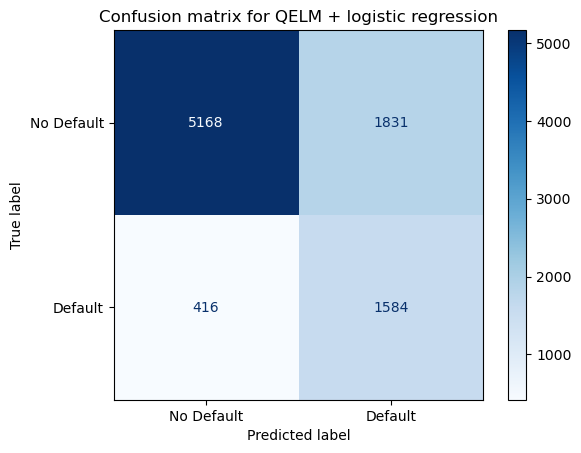

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred_quantum)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title("Confusion matrix for QELM + logistic regression")
plt.show()

In [16]:
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

False Positive Rate (FPR): 0.2616
False Negative Rate (FNR): 0.2080
